In [12]:
%matplotlib inline
import random
import torch
from d2l import torch as d2l

In [16]:
def synthetic_data(w,b,num_examples):
    X=torch.normal(0,1,(num_examples,len(w)))
    y=torch.matmul(X,w)+b
    y+=torch.normal(0,0.01,y.shape)
    return X,y.reshape(-1,1)

true_w=torch.tensor([2,-3.4])
true_b=4.2
features,labels=synthetic_data(true_w,true_b,1000)

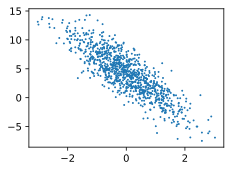

In [17]:
d2l.set_figsize()
d2l.plt.scatter(features[:,1].detach().numpy(),labels.detach().numpy(),1)

In [32]:
def data_iter(batch_size,features,labels):
    num_examples=len(features)
    indices=list(range(num_examples))
    random.shuffle(indices)
    for i in range(0,num_examples,batch_size):
        batch_indices=torch.tensor(indices[i:min(i+batch_size,num_examples)])
        yield features[batch_indices],labels[batch_indices]

batch_size=10

for X,y in data_iter(batch_size,features,labels):
    print(X,'\_n',y)
    break

tensor([[ 1.4438,  1.9510],
        [-0.7591,  1.7314],
        [-1.4989,  0.0188],
        [ 1.5661,  0.4407],
        [ 0.4884, -0.0857],
        [ 1.0412, -0.6583],
        [ 0.9614, -0.3435],
        [-0.5123,  1.2028],
        [-1.0132,  1.1631],
        [ 0.4812, -0.4154]]) \_n tensor([[ 0.4589],
        [-3.2122],
        [ 1.1439],
        [ 5.8203],
        [ 5.4680],
        [ 8.4990],
        [ 7.2904],
        [-0.9134],
        [-1.7655],
        [ 6.5785]])


In [39]:
w=torch.normal(0,0.01,size=(2,1),requires_grad=True)
b=torch.zeros(1,requires_grad=True)


In [24]:
def linreg(X,w,b):
    return torch.matmul(X,w)+b

In [27]:
def squared_loss(y_hat,y):
    return (y_hat-y.reshape(y_hat.shape))**2/2

In [26]:
def sgd(params,lr,batch_size):
    with torch.no_grad():
        for param in params:
            param-=lr*param.grad/batch_size
            param.grad.zero_()

In [40]:
lr=0.03
num_epochs=3
net=linreg
loss=squared_loss
for epoch in range(num_epochs):
    for X,y in data_iter(batch_size,features,labels):
        l=loss(net(X,w,b),y)
        l.sum().backward()
        sgd([w,b],lr,batch_size)
    with torch.no_grad():
        train_1=loss(net(features,w,b),labels)
        print(f'epoch{epoch+1},loss {train_1.mean():f}')


epoch1,loss 0.042455
epoch2,loss 0.000162
epoch3,loss 0.000048


In [41]:
print(f'w误差:{true_w-w.reshape(true_w.shape)}')

w误差:tensor([ 0.0002, -0.0009], grad_fn=<SubBackward0>)
